In [198]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from pathlib import Path


In [199]:
# Conectar con la base de datos y cargar las 3 tablas
import sqlite3

# Crear la conexión a la base de datos
conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')

listings = pd.read_sql_query("SELECT * FROM listings", conn)
listings_det = pd.read_sql_query("SELECT * FROM listings_det", conn)
precio = pd.read_sql_query("SELECT * FROM idealista", conn)

conn.close()

In [200]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 18708 entries, 0 to 18707
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   18708 non-null  int64  
 1   name                 18708 non-null  str    
 2   neighbourhood_group  18708 non-null  str    
 3   neighbourhood        18708 non-null  str    
 4   latitude             18708 non-null  float64
 5   longitude            18708 non-null  float64
 6   room_type            18708 non-null  str    
 7   price                18708 non-null  float64
 8   minimum_nights       18708 non-null  int64  
 9   availability_365     18708 non-null  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 1.4 MB


In [201]:
# Cambiar el tipo de dato de las columnas name, neighborhood, neighborhood_group, room_type a object
listings['name'] = listings['name'].astype(object)
listings['neighbourhood'] = listings['neighbourhood'].astype(object)
listings['neighbourhood_group'] = listings['neighbourhood_group'].astype(object)
listings['room_type'] = listings['room_type'].astype(object)

In [202]:
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 14067 entries, 0 to 14066
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         14067 non-null  int64  
 1   description                13692 non-null  str    
 2   accommodates               14067 non-null  int64  
 3   bathrooms                  14067 non-null  float64
 4   bedrooms                   14067 non-null  float64
 5   beds                       14067 non-null  float64
 6   review_scores_location     14067 non-null  float64
 7   estimated_occupancy_l365d  14067 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 879.3 KB


In [203]:
# Cambiar la columna description a object
listings_det['description'] = listings_det['description'].astype(object)

In [204]:
precio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   precio    21 non-null     int64
 1   distrito  21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [205]:
# Cambiar la columna distrito a object
precio['distrito'] = precio['distrito'].astype(object)

In [206]:
# Merge inner join entre listings y listings_det
df_listings = listings.merge(listings_det, on='id', how='inner')

In [207]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 13984 entries, 0 to 13983
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         13984 non-null  int64  
 1   name                       13984 non-null  object 
 2   neighbourhood_group        13984 non-null  object 
 3   neighbourhood              13984 non-null  object 
 4   latitude                   13984 non-null  float64
 5   longitude                  13984 non-null  float64
 6   room_type                  13984 non-null  object 
 7   price                      13984 non-null  float64
 8   minimum_nights             13984 non-null  int64  
 9   availability_365           13984 non-null  int64  
 10  description                13610 non-null  object 
 11  accommodates               13984 non-null  int64  
 12  bathrooms                  13984 non-null  float64
 13  bedrooms                   13984 non-null  float64
 14  b

In [208]:
# Merge entre df_listings y precio (left join)
df = df_listings.merge(precio, left_on='neighbourhood_group', right_on='distrito', how='left')

In [209]:
# Eliminar neighbourhood_group
df = df.drop(columns=['id','neighbourhood_group'])

In [210]:
# Renombrar la columna price a precio_noche y precio a precio_m2
df = df.rename(columns={'price': 'precio_noche', 'precio': 'precio_m2'})

In [213]:
# Eliminar filas con availability_365 menor a 180
df = df[df['availability_365'] >= 180]

In [215]:
df.shape

(8292, 17)

In [216]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,1.0,1.0,2.0,4.90,10,7524,Centro
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,1.0,1.0,3.0,4.88,40,7524,Centro
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,4.97,246,7524,Centro
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,1.0,1.0,1.0,4.60,60,7524,Centro
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,1.0,1.0,2.0,4.87,120,7524,Centro


In [217]:
def calcular_precio_noche_total(row):
    tasa_uso = 0.5
    if row['room_type'] == 'Entire home/apt':
        return row['precio_noche']
    elif row['room_type'] == 'Private room':
        if row['bedrooms'] > 1:
            return row['precio_noche'] * row['bedrooms'] * tasa_uso
        else:
            return row['precio_noche']
    elif row['room_type'] == 'Shared room':
        if row['accommodates'] > 1:
            return row['precio_noche'] * row['accommodates'] * tasa_uso
        else:
            return row['precio_noche']
    else:
        return np.nan

df['precio_noche_total'] = df.apply(calcular_precio_noche_total, axis=1)


In [218]:
# Crear una variable ingreso anual que multiplique el precio_noche_total por estimated_occupancy_l365d
df['ingreso_anual'] = df['precio_noche_total'] * df['estimated_occupancy_l365d']

In [219]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,1.0,1.0,2.0,4.90,10,7524,Centro,157.0,1570.0
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,1.0,1.0,3.0,4.88,40,7524,Centro,143.0,5720.0
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,4.97,246,7524,Centro,65.0,15990.0
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,1.0,1.0,1.0,4.60,60,7524,Centro,116.0,6960.0
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,1.0,1.0,2.0,4.87,120,7524,Centro,79.0,9480.0


In [220]:
condiciones_m2= [
    (df['bedrooms'] == 0),
    (df['bedrooms'] == 1),
    (df['bedrooms'] == 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] < 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] >= 2),
    (df['bedrooms'] > 3) | (df['bathrooms'] >= 3)
]

valores_m2 = [35, 50, 65, 90, 110, 140]

df['m2_estimado'] = np.select(condiciones_m2, valores_m2, default=np.nan)

In [221]:
# Crear una nueva variable llamada coste_adquisicion que multiplique el m2_estimado por el precio_m2 y multiplicar por un ajuste de 0.75
df['coste_adquisicion'] = df['m2_estimado'] * df['precio_m2'] * 0.75

In [222]:
df.head(15)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion
0,Apartamentos Dana Sol,Sol,40.414760,-3.704180,Entire home/apt,157.0,5,342,NaN,2,...,1.0,2.0,4.90,10,7524,Centro,157.0,1570.0,50.0,282150.0
1,Apartasol Apartamentos Dana,Universidad,40.422470,-3.705770,Entire home/apt,143.0,5,341,NaN,2,...,1.0,3.0,4.88,40,7524,Centro,143.0,5720.0,50.0,282150.0
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.418840,-3.696550,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,...,1.0,2.0,4.97,246,7524,Centro,65.0,15990.0,50.0,282150.0
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.422520,-3.702500,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,...,1.0,1.0,4.60,60,7524,Centro,116.0,6960.0,50.0,282150.0
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.422520,-3.702500,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,...,1.0,2.0,4.87,120,7524,Centro,79.0,9480.0,50.0,282150.0
5,Sunny attic duplex flat with terrace next to Sol,Embajadores,40.411500,-3.704490,Entire home/apt,300.0,3,180,"Nestled in the serene heart of Madrid, this re...",6,...,3.0,5.0,4.84,90,7524,Centro,300.0,27000.0,90.0,507870.0
8,private house B & B. Arturo Soria (Metro),Piovera,40.455750,-3.649120,Private room,90.0,1,336,"Residential area, very quite house, no more gu...",2,...,1.0,2.0,4.84,54,5321,Hortaleza,90.0,4860.0,50.0,199537.5
9,Habitación en ático muy céntrico con dos terrazas,Universidad,40.425700,-3.703830,Private room,60.0,2,257,"Room with new orthopedic mattress, ceiling fan...",2,...,1.0,1.0,4.96,156,7524,Centro,60.0,9360.0,50.0,282150.0
12,Tafari Gran Via - Alquiler Temporal,Universidad,40.421160,-3.703840,Entire home/apt,98.0,15,319,NaN,2,...,0.0,1.0,4.94,255,7524,Centro,98.0,24990.0,35.0,197505.0
13,Private Room in a Sunny and Luxuriously Appoin...,Canillas,40.459590,-3.646990,Private room,68.0,2,308,Set a traditional dining table and enjoy a del...,2,...,1.0,1.0,4.81,186,5321,Hortaleza,68.0,12648.0,50.0,199537.5


In [223]:
# Crear una media de adquisicion por distrito y mostrarla ordenada de mayor a menor
df.groupby('distrito')['coste_adquisicion'].mean().reset_index().sort_values(by='coste_adquisicion', ascending=False)

,distrito,coste_adquisicion
14,Salamanca,482287.310393
5,Chamberí,388948.807157
4,Chamartín,350527.276646
13,Retiro,343007.484076
3,Centro,322395.882353
10,Moncloa - Aravaca,268909.600515
0,Arganzuela,261326.149103
16,Tetuán,251018.915563
7,Fuencarral - El Pardo,240486.458333
8,Hortaleza,231098.333333


In [224]:
import sys
sys.path.append('../funciones')
from funciones import tourism_index

In [225]:
# Cargar los CSV y convertirlos a diccionarios
df_pois = pd.read_csv('../datos/brutos/poi_madrid.csv')
pois = dict(zip(df_pois['nombre'], zip(df_pois['latitud'], df_pois['longitud'])))

df_weights = pd.read_csv('../datos/brutos/poi_madrid_weights.csv')
weights = dict(zip(df_weights['nombre'], df_weights['peso']))

# Calcular el atractivo turístico
df['atractivo_turistico'] = df.apply(
    lambda row: tourism_index(row['latitude'], row['longitude'], pois, weights), axis=1
)

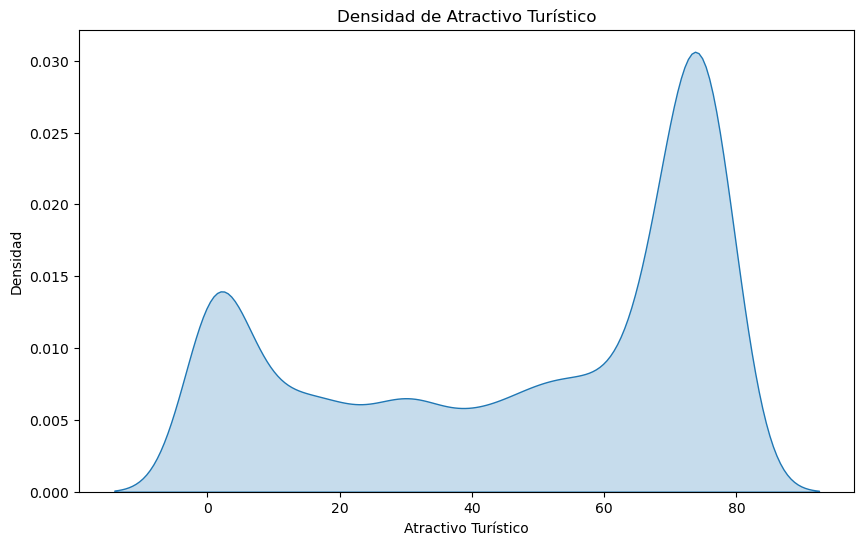

In [226]:
# Grafico de densidad de atractivo turistico
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='atractivo_turistico', fill=True)
plt.title('Densidad de Atractivo Turístico')
plt.xlabel('Atractivo Turístico')
plt.ylabel('Densidad')
plt.show()

In [227]:
# Ordenar df por atractivo turistico de menor a mayor
df.sort_values(by='atractivo_turistico', ascending=True)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico
9379,campezo,Rejas,40.442403,-3.581939,Entire home/apt,150.0,1,337,just 7.6 m from Gran Via Station Metro Station...,3,...,1.0,4.50,12,3959,San Blas - Canillejas,150.0,1800.0,50.0,148462.5,0.000000
9390,Jolie maison avec jardin,Palomas,40.452820,-3.611970,Entire home/apt,273.0,3,314,This peaceful home offers a relaxing stay for ...,6,...,6.0,4.50,24,5321,Hortaleza,273.0,6552.0,140.0,558705.0,0.000000
9327,Bonito Apartamento para 3pax en Vallecas,Casco Histórico de Vallecas,40.374634,-3.608583,Entire home/apt,91.0,1,279,This apartment in Ensanche de Vallecas is idea...,3,...,2.0,4.84,126,3674,Villa de Vallecas,91.0,11466.0,65.0,179107.5,0.000000
150,Well connected Guesthouse in Madrid's green belt,Valverde,40.503770,-3.688840,Entire home/apt,88.0,4,325,Independent fully equipped 30sqm house + 25sqm...,2,...,1.0,4.81,152,5369,Fuencarral - El Pardo,88.0,13376.0,50.0,201337.5,0.000000
9221,Cómodo piso familiar en Canillejas,Canillejas,40.442646,-3.608000,Entire home/apt,86.0,2,315,"Relax as a family in this quiet home, in a per...",4,...,3.0,4.92,102,3959,San Blas - Canillejas,86.0,8772.0,50.0,148462.5,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577,Bright with style -2Bedrooms 2Baths-Puerta del...,Sol,40.417050,-3.704180,Entire home/apt,211.0,1,275,Renovated and spacious apartment with balconie...,5,...,4.0,4.92,210,7524,Centro,211.0,44310.0,65.0,366795.0,78.418674
5361,Waou Apartamentos en Sol Confort 5,Sol,40.417240,-3.703560,Entire home/apt,292.0,1,298,Wonderful two bedroom apartment in the middle ...,6,...,4.0,4.86,18,7524,Centro,292.0,5256.0,65.0,366795.0,78.422803
9438,Estudio exterior 504 M-15,Sol,40.416963,-3.703604,Entire home/apt,114.0,1,313,Base this home and you'll be a step away from ...,2,...,1.0,4.87,255,7524,Centro,114.0,29070.0,50.0,282150.0,78.422901
133,Best Deal Chic VELAZQUEZ SUITE SOL,Sol,40.416880,-3.703840,Entire home/apt,159.0,2,202,NaN,5,...,3.0,4.86,255,7524,Centro,159.0,40545.0,65.0,366795.0,78.433612


In [228]:
df.columns

Index(['name', 'neighbourhood', 'latitude', 'longitude', 'room_type',
       'precio_noche', 'minimum_nights', 'availability_365', 'description',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'review_scores_location', 'estimated_occupancy_l365d', 'precio_m2',
       'distrito', 'precio_noche_total', 'ingreso_anual', 'm2_estimado',
       'coste_adquisicion', 'atractivo_turistico'],
      dtype='str')

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\2946063088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='accommodates', palette='viridis')


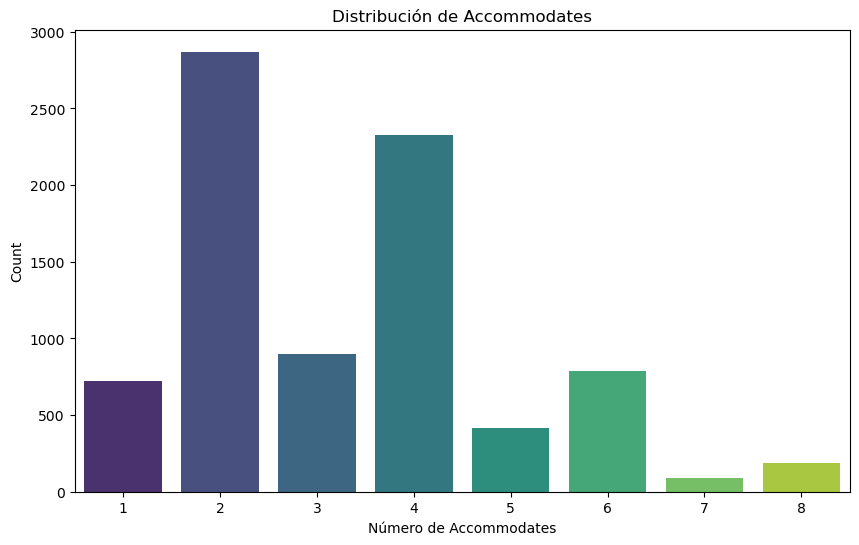

In [229]:
 # Genera un grafico de barras de bedrooms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='accommodates', palette='viridis')
plt.title('Distribución de Accommodates')
plt.xlabel('Número de Accommodates')
plt.ylabel('Count')
plt.show()

In [230]:
# Discretizar beds en las categorías '0', '1', '2', '3', '> 3'
df['beds_disc'] = pd.cut(df['beds'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['01_cama', '02_camas', '03_camas', '04_camas', '> 05_camas'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\164970981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='beds_disc', order=orden_beds, palette='viridis')


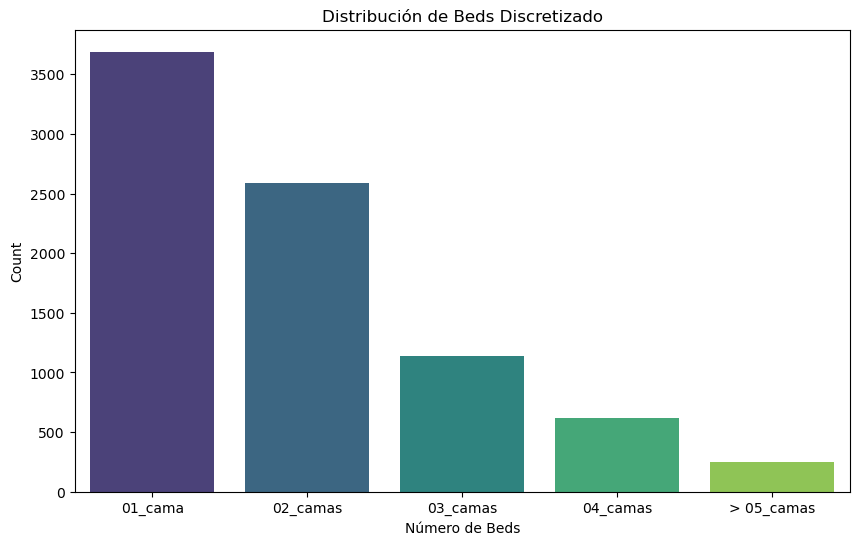

In [231]:
# Grafico de baaras de beds discretizado con tamaño personalizado
orden_beds = ['01_cama', '02_camas', '03_camas', '04_camas', '> 05_camas']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='beds_disc', order=orden_beds, palette='viridis')
plt.title('Distribución de Beds Discretizado')
plt.xlabel('Número de Beds')
plt.ylabel('Count')
plt.show() 

In [232]:
# Discretizar bathrooms en las categorías '<= 1', '1 - 2', '> 2'
df['bathrooms_disc'] = pd.cut(df['bathrooms'], bins=[-np.inf, 1, 2, np.inf], labels=['<= 1_toilet', '1 - 2 toilets', '> 2 toilets'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\1146154502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='bathrooms_disc', palette='viridis', order=orden)


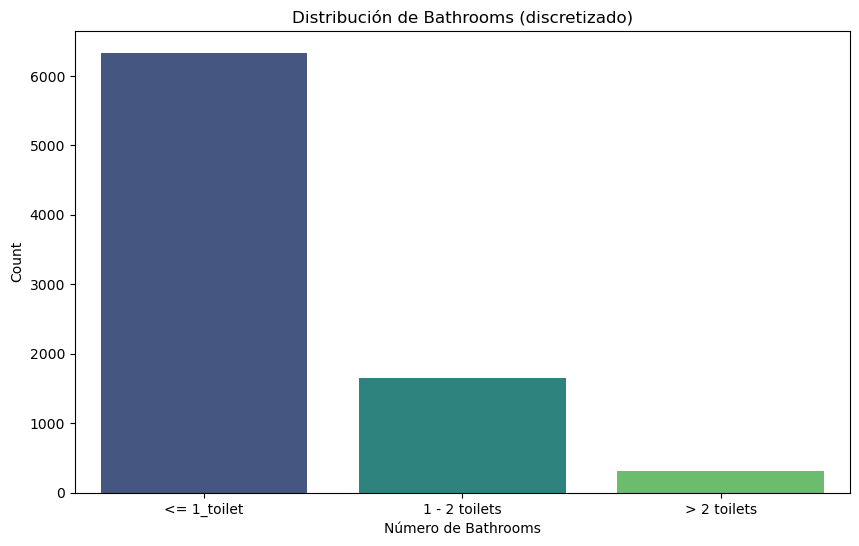

In [233]:
# Gráfico de barras de bathrooms discretizado con tamaño personalizado
orden = ['<= 1_toilet', '1 - 2 toilets', '> 2 toilets']
df['bathrooms_disc'] = pd.Categorical(df['bathrooms_disc'], categories=orden, ordered=True)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bathrooms_disc', palette='viridis', order=orden)
plt.title('Distribución de Bathrooms (discretizado)')
plt.xlabel('Número de Bathrooms')
plt.ylabel('Count')
plt.show()

In [234]:
# Discretizar accommodates en las categorías '1', '2', '3', '4', '> 5'
df['accommodates_disc'] = pd.cut(df['accommodates'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['1', '2', '3', '4', '> 5'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\3564817298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='accommodates_disc', order=orden_accommodates, palette='viridis')


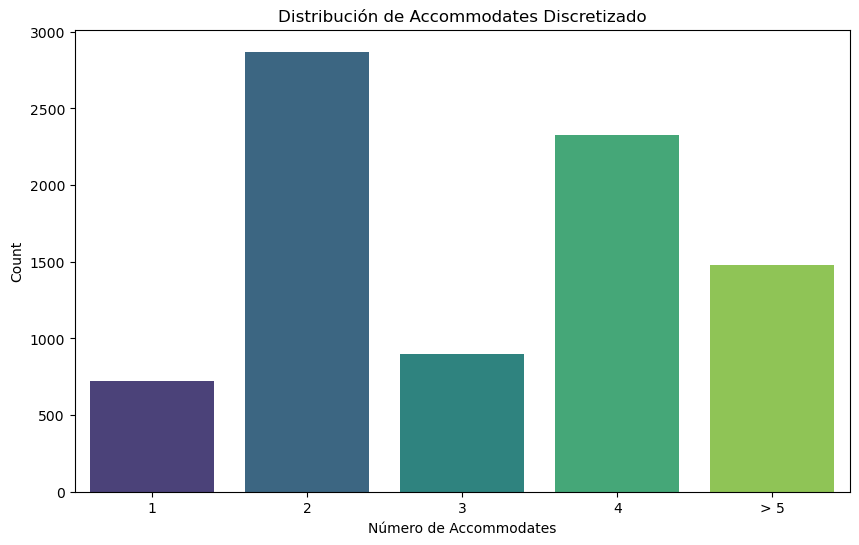

In [235]:
# Grafico de barras de accommodates discretizado con tamaño personalizado
orden_accommodates = ['1', '2', '3', '4', '> 5']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='accommodates_disc', order=orden_accommodates, palette='viridis')
plt.title('Distribución de Accommodates Discretizado')
plt.xlabel('Número de Accommodates')
plt.ylabel('Count')
plt.show()  
    

In [236]:
# Discretizar beds en las categorías '<=1', '2', '3', '4', '> 5'
df['bedrooms_disc'] = pd.cut(df['beds'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['01_hab', '02_habs', '03_habs', '04_habs', '> 05_habs'])

C:\Users\phdel\AppData\Local\Temp\ipykernel_14284\3094543556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='bedrooms_disc', order=orden_bedrooms, palette='viridis')


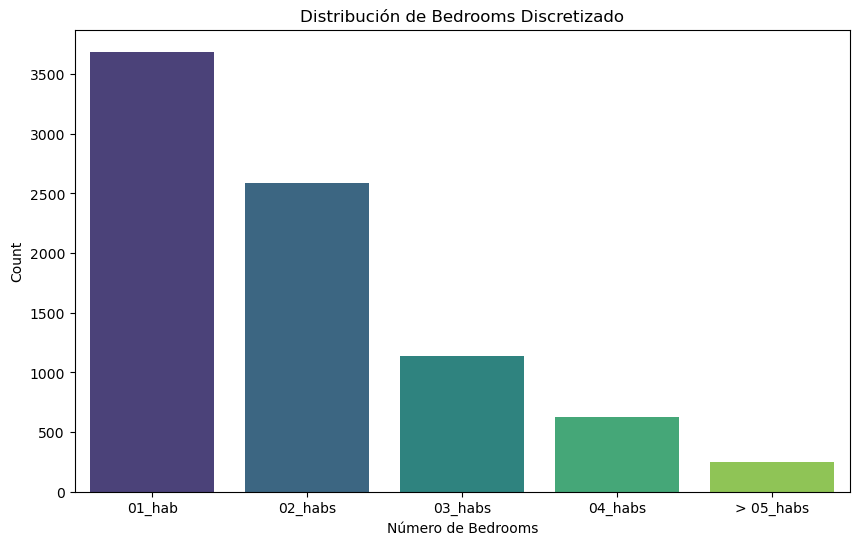

In [237]:
# Grafico de barras de bedrooms discretizado con tamaño personalizado
orden_bedrooms = ['01_hab', '02_habs', '03_habs', '04_habs', '> 05_habs']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bedrooms_disc', order=orden_bedrooms, palette='viridis')
plt.title('Distribución de Bedrooms Discretizado')
plt.xlabel('Número de Bedrooms')
plt.ylabel('Count')
plt.show()  

In [243]:
# Crea una variable margen_bruto que sea el resultado de dividir el ingreso_anual entre el coste_adquisicion
df['margen_bruto'] = ((df['ingreso_anual'] / df['coste_adquisicion']) * 100).round(2)

In [244]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico,beds_disc,bathrooms_disc,accommodates_disc,bedrooms_disc,coste_bruto,margen_bruto
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342,NaN,2,...,1570.0,50.0,282150.0,77.342690,02_camas,<= 1_toilet,2,02_habs,0.005564,0.556442
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341,NaN,2,...,5720.0,50.0,282150.0,75.210312,03_camas,<= 1_toilet,2,03_habs,0.020273,2.027290
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,299,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,...,15990.0,50.0,282150.0,75.768644,02_camas,1 - 2 toilets,4,02_habs,0.056672,5.667198
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,305,Beautiful apartment with spacious living room ...,2,...,6960.0,50.0,282150.0,75.339969,01_cama,<= 1_toilet,2,01_hab,0.024668,2.466773
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,317,Cozy Apartment in great location in the center...,2,...,9480.0,50.0,282150.0,75.339969,02_camas,<= 1_toilet,2,02_habs,0.033599,3.359915


In [240]:
# Crea una nueva tabla en la base de datos mercado inmobiliario.db que se llame tablon_analitico con el dataframe df
conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')
df.to_sql('tablon_analitico', conn, if_exists='replace', index=False)
conn.close()